# 基于 Python 的中国新能源汽车数据清洗与分析

**课程：** 数据清洗  
**姓名学号：** 2023109223 刘文博  
**数据主题：** 中国新能源汽车年度销量、中国汽车月度产量、中国与全球电动汽车销量对比

本 Notebook 使用中国新能源汽车相关公开统计数据作为案例，围绕时间序列补全、缺失值处理、异常值处理、特征构造、趋势分析和可视化展示完成数据清洗综合应用实践。

## 1. 数据来源

本案例使用 China Data Portal 提供的免费 API，数据说明中标注的原始统计口径如下：

- 中国新能源汽车年度销量：来源为中国汽车工业协会 CAAM，单位为万辆，年度频率。
- 中国汽车月度产量：来源为国家统计局 NBS，单位为万辆，月度频率。
- 中国与全球电动汽车销量对比：来源为 IEA、EV-Volumes、中国汽车工业协会等，单位为百万辆，年度频率。

选择这些数据的原因是：新能源汽车是国内当前热点产业；数据具有中国政策和市场背景；月度数据存在未报告月份，适合展示时间序列补全和缺失处理。

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="SimHei")

cwd = Path.cwd()
BASE_DIR = cwd if cwd.name == "期末考试" else cwd / "数据清洗" / "期末考试"
OUT_DIR = BASE_DIR / "output"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "china_nev_sales": {
        "url": "https://chinadata.live/api/v2/data/china-nev-sales",
        "name": "中国新能源汽车年度销量",
        "source": "中国汽车工业协会 CAAM",
    },
    "china_car_production_monthly": {
        "url": "https://chinadata.live/api/v2/data/china-car-production-monthly",
        "name": "中国汽车月度产量",
        "source": "国家统计局 NBS",
    },
    "ev_sales_china_vs_world": {
        "url": "https://chinadata.live/api/v2/data/ev-sales-china-vs-world",
        "name": "中国与全球电动汽车销量对比",
        "source": "IEA、EV-Volumes、中国汽车工业协会",
    },
}

print("工作目录:", BASE_DIR)

工作目录: C:\my_code\learning-notes\数据清洗\期末考试


## 2. 获取公开数据

下面通过 API 在线获取三个数据集，并保存原始 CSV 副本，保证后续结果可以复现。

In [2]:
def fetch_dataset(key: str) -> tuple[pd.DataFrame, dict]:
    meta = DATASETS[key]
    response = requests.get(meta["url"], timeout=60)
    response.raise_for_status()
    payload = response.json()["data"]
    df = pd.DataFrame(payload["data"])
    df.to_csv(OUT_DIR / f"raw_{key}.csv", index=False, encoding="utf-8-sig")
    return df, payload


raw_nev, meta_nev = fetch_dataset("china_nev_sales")
raw_monthly, meta_monthly = fetch_dataset("china_car_production_monthly")
raw_compare, meta_compare = fetch_dataset("ev_sales_china_vs_world")

print("新能源汽车年度销量:", raw_nev.shape)
print("汽车月度产量:", raw_monthly.shape)
print("中国与全球电动车销量对比:", raw_compare.shape)
display(raw_nev.head())
display(raw_monthly.head())
display(raw_compare.head())

新能源汽车年度销量: (14, 2)
汽车月度产量: (164, 2)
中国与全球电动车销量对比: (11, 5)


,date,value
0,2011,0.80
1,2012,1.30
2,2013,1.76
3,2014,7.48
4,2015,33.10


,date,value
0,2010-02,61.8
1,2010-03,89.7
2,2010-04,78.6
3,2010-05,71.8
4,2010-06,72.1


,date,china,world_total,world_minus_china,china_share
0,2015,0.33,0.55,0.22,60.0
1,2016,0.51,0.78,0.27,65.4
2,2017,0.78,1.22,0.44,63.9
3,2018,1.26,2.02,0.76,62.4
4,2019,1.21,2.25,1.04,53.8


## 3. 原始数据质量评估

月度产量数据原始记录不是完整月份序列，国家统计局部分年份的 1 月或 2 月数据通常不单独报告。为了做时间序列分析，需要先补齐完整月份，再对未报告月份进行标记和填补。

In [3]:
def missing_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    return (
        pd.DataFrame({
            "stage": label,
            "column": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_rate": (df.isna().mean().values * 100).round(2),
        })
        .sort_values(["missing_count", "column"], ascending=[False, True])
        .reset_index(drop=True)
    )


def profile_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        rows.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "non_null_count": int(df[col].notna().sum()),
            "missing_count": int(df[col].isna().sum()),
            "unique_count": int(df[col].nunique(dropna=True)),
        })
    return pd.DataFrame(rows)


monthly_raw_for_check = raw_monthly.copy()
monthly_raw_for_check.columns = ["date", "production_10k"]
monthly_raw_for_check["date"] = pd.to_datetime(monthly_raw_for_check["date"], format="%Y-%m")
monthly_raw_for_check["production_10k"] = pd.to_numeric(monthly_raw_for_check["production_10k"], errors="coerce")
full_months_for_check = pd.DataFrame({
    "date": pd.date_range(monthly_raw_for_check["date"].min(), monthly_raw_for_check["date"].max(), freq="MS")
})
monthly_before = full_months_for_check.merge(monthly_raw_for_check, on="date", how="left")
monthly_before["year"] = monthly_before["date"].dt.year
monthly_before["month"] = monthly_before["date"].dt.month
monthly_before["quarter"] = monthly_before["date"].dt.quarter
missing_before = missing_table(monthly_before, "填补前")
raw_profile = profile_table(monthly_before)

print("原始 API 表格空单元格缺失值总数:", int(raw_monthly.isna().sum().sum()))
print("补齐完整月份后、填补前缺失值总数:", int(monthly_before.isna().sum().sum()))
print("原始 API 月度记录数:", len(raw_monthly))
print("补齐完整月份后记录数:", len(monthly_before))
display(missing_before)
display(raw_profile)

原始 API 表格空单元格缺失值总数: 0
补齐完整月份后、填补前缺失值总数: 27
原始 API 月度记录数: 164
补齐完整月份后记录数: 191


,stage,column,missing_count,missing_rate
0,填补前,production_10k,27,14.14
1,填补前,date,0,0.00
2,填补前,month,0,0.00
3,填补前,quarter,0,0.00
4,填补前,year,0,0.00


,column,dtype,non_null_count,missing_count,unique_count
0,date,datetime64[ns],191,0,191
1,production_10k,float64,164,27,140
2,year,int64,191,0,16
3,month,int64,191,0,12
4,quarter,int64,191,0,4


## 4. 月度产量数据清洗

主要步骤包括：字段规范化、补齐完整月份、保留缺失标记、同月历史中位数填补、IQR 异常值检查、同比增速和季度等时间特征构造。

In [4]:
def cap_by_iqr(series: pd.Series) -> tuple[pd.Series, float, float, int]:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return series.clip(lower, upper), round(lower, 4), round(upper, 4), int(mask.sum())


cleaning_log = []
monthly = raw_monthly.copy()
monthly.columns = ["date", "production_10k"]
monthly["date"] = pd.to_datetime(monthly["date"], format="%Y-%m")
monthly["production_10k"] = pd.to_numeric(monthly["production_10k"], errors="coerce")
monthly = monthly.drop_duplicates(subset=["date"]).sort_values("date")
cleaning_log.append({"step": "字段规范化", "detail": "将月度产量字段统一为 date、production_10k，并转换日期类型。"})

full_months = pd.DataFrame({"date": pd.date_range(monthly["date"].min(), monthly["date"].max(), freq="MS")})
monthly_clean = full_months.merge(monthly, on="date", how="left")
monthly_clean["year"] = monthly_clean["date"].dt.year
monthly_clean["month"] = monthly_clean["date"].dt.month
monthly_clean["quarter"] = monthly_clean["date"].dt.quarter
monthly_clean["production_missing_flag"] = monthly_clean["production_10k"].isna().astype(int)
inserted_missing = int(monthly_clean["production_missing_flag"].sum())
cleaning_log.append({"step": "补全时间索引", "detail": f"补齐完整月份序列，新增 {inserted_missing} 条原始未报告月份。"})

month_median = monthly_clean.groupby("month")["production_10k"].transform("median")
monthly_clean["production_filled_10k"] = monthly_clean["production_10k"].fillna(month_median).fillna(monthly_clean["production_10k"].median())
monthly_clean["production_before_cap_10k"] = monthly_clean["production_filled_10k"]
monthly_clean["production_filled_10k"], production_low, production_high, production_outliers = cap_by_iqr(monthly_clean["production_filled_10k"])
monthly_clean["production_filled_10k"] = monthly_clean["production_filled_10k"].round(2)
monthly_clean["production_10k"] = monthly_clean["production_10k"].fillna(monthly_clean["production_filled_10k"]).round(2)
cleaning_log.append({"step": "缺失值和异常值处理", "detail": f"缺失值使用同月历史中位数填补；IQR 截尾范围 [{production_low}, {production_high}]，调整 {production_outliers} 个值。"})

monthly_clean["production_yoy"] = monthly_clean["production_filled_10k"].pct_change(12).replace([np.inf, -np.inf], np.nan).fillna(0).round(4)
monthly_clean["production_level"] = pd.qcut(
    monthly_clean["production_filled_10k"].rank(method="first"),
    q=4,
    labels=["低产量", "中低产量", "中高产量", "高产量"],
)
monthly_clean["month_name"] = monthly_clean["month"].astype(str).str.zfill(2) + "月"
cleaning_log.append({"step": "特征构造", "detail": "新增 year、month、quarter、production_yoy、production_level 等字段。"})

missing_after = missing_table(monthly_clean, "清洗后")
print("补齐后的月度数据规模:", monthly_clean.shape)
print("清洗后缺失值总数:", int(monthly_clean.isna().sum().sum()))
display(pd.DataFrame(cleaning_log))
display(monthly_clean.head())
display(missing_after)

补齐后的月度数据规模: (191, 11)
清洗后缺失值总数: 0


,step,detail
0,字段规范化,将月度产量字段统一为 date、production_10k，并转换日期类型。
1,补全时间索引,补齐完整月份序列，新增 27 条原始未报告月份。
2,缺失值和异常值处理,"缺失值使用同月历史中位数填补；IQR 截尾范围 [54.6, 132.2]，调整 3 个值。"
3,特征构造,新增 year、month、quarter、production_yoy、productio...


,date,production_10k,year,month,quarter,production_missing_flag,production_filled_10k,production_before_cap_10k,production_yoy,production_level,month_name
0,2010-02-01,61.8,2010,2,1,0,61.8,61.8,0.0,低产量,02月
1,2010-03-01,89.7,2010,3,1,0,89.7,89.7,0.0,中低产量,03月
2,2010-04-01,78.6,2010,4,2,0,78.6,78.6,0.0,低产量,04月
3,2010-05-01,71.8,2010,5,2,0,71.8,71.8,0.0,低产量,05月
4,2010-06-01,72.1,2010,6,2,0,72.1,72.1,0.0,低产量,06月


,stage,column,missing_count,missing_rate
0,清洗后,date,0,0.0
1,清洗后,month,0,0.0
2,清洗后,month_name,0,0.0
3,清洗后,production_10k,0,0.0
4,清洗后,production_before_cap_10k,0,0.0
5,清洗后,production_filled_10k,0,0.0
6,清洗后,production_level,0,0.0
7,清洗后,production_missing_flag,0,0.0
8,清洗后,production_yoy,0,0.0
9,清洗后,quarter,0,0.0


## 5. 年度新能源汽车数据清洗与合并

年度表将新能源汽车销量、汽车年度产量汇总、中国与全球电动车销量对比合并到同一年份上，并构造同比增速、全球占比、政策阶段等字段。

In [5]:
nev = raw_nev.copy()
nev.columns = ["year", "nev_sales_10k"]
nev["year"] = pd.to_numeric(nev["year"], errors="coerce").astype(int)
nev["nev_sales_10k"] = pd.to_numeric(nev["nev_sales_10k"], errors="coerce")
nev = nev.drop_duplicates(subset=["year"]).sort_values("year")

compare = raw_compare.copy()
compare["year"] = pd.to_numeric(compare["date"], errors="coerce").astype(int)
compare = compare.drop(columns=["date"]).rename(
    columns={
        "china": "china_ev_sales_million",
        "world_total": "world_ev_sales_million",
        "world_minus_china": "world_minus_china_million",
        "china_share": "china_world_share_pct",
    }
)
for col in ["china_ev_sales_million", "world_ev_sales_million", "world_minus_china_million", "china_world_share_pct"]:
    compare[col] = pd.to_numeric(compare[col], errors="coerce")

annual_prod = (
    monthly_clean.groupby("year", as_index=False)
    .agg(
        car_production_10k=("production_filled_10k", "sum"),
        reported_months=("production_missing_flag", lambda s: int((s == 0).sum())),
        filled_months=("production_missing_flag", "sum"),
    )
    .round({"car_production_10k": 2})
)

annual = nev.merge(annual_prod, on="year", how="left").merge(compare, on="year", how="left")
annual["nev_sales_million"] = (annual["nev_sales_10k"] / 100).round(4)
annual["nev_sales_yoy"] = annual["nev_sales_10k"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0).round(4)
annual["nev_to_car_output_ratio_pct"] = (annual["nev_sales_10k"] / annual["car_production_10k"] * 100).round(2)
annual["policy_stage"] = pd.cut(
    annual["year"],
    bins=[2010, 2015, 2020, 2025],
    labels=["示范推广期", "补贴调整期", "规模化增长期"],
    include_lowest=True,
)
annual = annual.fillna({
    "china_ev_sales_million": 0,
    "world_ev_sales_million": 0,
    "world_minus_china_million": 0,
    "china_world_share_pct": 0,
})
cleaning_log.append({"step": "年度数据合并", "detail": "合并年度销量、年度产量汇总和全球对比数据，新增同比增速、全球占比和政策阶段。"})

print("年度清洗表规模:", annual.shape)
print("年度清洗表缺失值总数:", int(annual.isna().sum().sum()))
display(annual)

年度清洗表规模: (14, 13)
年度清洗表缺失值总数: 0


,year,nev_sales_10k,car_production_10k,reported_months,filled_months,china_ev_sales_million,world_ev_sales_million,world_minus_china_million,china_world_share_pct,nev_sales_million,nev_sales_yoy,nev_to_car_output_ratio_pct,policy_stage
0,2011,0.80,1043.1,11,1,0.00,0.00,0.00,0.0,0.0080,0.0000,0.08,示范推广期
1,2012,1.30,1137.1,11,1,0.00,0.00,0.00,0.0,0.0130,0.6250,0.11,示范推广期
2,2013,1.76,1288.6,10,2,0.00,0.00,0.00,0.0,0.0176,0.3538,0.14,示范推广期
3,2014,7.48,1302.1,10,2,0.00,0.00,0.00,0.0,0.0748,3.2500,0.57,示范推广期
4,2015,33.10,1150.2,11,1,0.33,0.55,0.22,60.0,0.3310,3.4251,2.88,示范推广期
5,2016,50.70,1204.0,10,2,0.51,0.78,0.27,65.4,0.5070,0.5317,4.21,补贴调整期
6,2017,77.70,1190.6,10,2,0.78,1.22,0.44,63.9,0.7770,0.5325,6.53,补贴调整期
7,2018,125.60,1165.8,10,2,1.26,2.02,0.76,62.4,1.2560,0.6165,10.77,补贴调整期
8,2019,120.60,1041.9,10,2,1.21,2.25,1.04,53.8,1.2060,-0.0398,11.58,补贴调整期
9,2020,136.70,1031.8,10,2,1.37,3.12,1.75,43.9,1.3670,0.1335,13.25,补贴调整期


## 6. 保存清洗结果

输出两个清洗后的数据集：月度汽车产量清洗表、年度新能源汽车分析表；同时保存 Excel 质量汇总和 JSON 摘要。

In [6]:
monthly_clean.to_csv(OUT_DIR / "cleaned_china_car_production_monthly.csv", index=False, encoding="utf-8-sig")
annual.to_csv(OUT_DIR / "cleaned_china_nev_annual.csv", index=False, encoding="utf-8-sig")

quality_summary = {
    "topic": "中国新能源汽车与汽车产量数据清洗",
    "nev_source": meta_nev["source"],
    "monthly_source": meta_monthly["source"],
    "comparison_source": meta_compare["source"],
    "nev_year_start": int(annual["year"].min()),
    "nev_year_end": int(annual["year"].max()),
    "monthly_rows_raw": int(raw_monthly.shape[0]),
    "monthly_rows_clean": int(monthly_clean.shape[0]),
    "annual_rows_clean": int(annual.shape[0]),
    "missing_before_total": int(monthly_before.isna().sum().sum()),
    "missing_after_total": int(monthly_clean.isna().sum().sum()),
    "inserted_missing_months": inserted_missing,
    "latest_nev_year": int(annual["year"].max()),
    "latest_nev_sales_10k": float(annual.loc[annual["year"].idxmax(), "nev_sales_10k"]),
    "latest_nev_sales_million": float(annual.loc[annual["year"].idxmax(), "nev_sales_million"]),
    "latest_china_world_share_pct": float(annual.loc[annual["year"].idxmax(), "china_world_share_pct"]),
    "production_iqr_low": production_low,
    "production_iqr_high": production_high,
    "production_outliers": production_outliers,
}

with pd.ExcelWriter(OUT_DIR / "cleaning_summary.xlsx", engine="openpyxl") as writer:
    missing_before.to_excel(writer, sheet_name="missing_before", index=False)
    missing_after.to_excel(writer, sheet_name="missing_after", index=False)
    raw_profile.to_excel(writer, sheet_name="raw_profile", index=False)
    profile_table(monthly_clean).to_excel(writer, sheet_name="monthly_profile", index=False)
    profile_table(annual).to_excel(writer, sheet_name="annual_profile", index=False)
    pd.DataFrame(cleaning_log).to_excel(writer, sheet_name="cleaning_log", index=False)
    pd.DataFrame([quality_summary]).to_excel(writer, sheet_name="quality_summary", index=False)

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump({"quality_summary": quality_summary, "cleaning_log": cleaning_log}, f, ensure_ascii=False, indent=2)

(OUT_DIR / "data_source.txt").write_text(
    "主题: 中国新能源汽车与汽车产量数据清洗\n"
    f"新能源汽车年度销量 API: {DATASETS['china_nev_sales']['url']}\n"
    f"汽车月度产量 API: {DATASETS['china_car_production_monthly']['url']}\n"
    f"中国与全球电动汽车销量对比 API: {DATASETS['ev_sales_china_vs_world']['url']}\n"
    "主要数据来源: 中国汽车工业协会、国家统计局、IEA/EV-Volumes 等公开统计口径\n",
    encoding="utf-8",
)

display(pd.DataFrame([quality_summary]))

,topic,nev_source,monthly_source,comparison_source,nev_year_start,nev_year_end,monthly_rows_raw,monthly_rows_clean,annual_rows_clean,missing_before_total,missing_after_total,inserted_missing_months,latest_nev_year,latest_nev_sales_10k,latest_nev_sales_million,latest_china_world_share_pct,production_iqr_low,production_iqr_high,production_outliers
0,中国新能源汽车与汽车产量数据清洗,China Association of Automobile Manufacturers ...,National Bureau of Statistics of China (NBS),"IEA, EV-Volumes, China Association of Automobi...",2011,2024,164,191,14,27,0,27,2024,1286.6,12.866,64.7,54.6,132.2,3


## 7. 可视化分析

本节将图表分成两类：第一类是数据清洗前后对比图，只用于说明缺失值填补和异常值处理效果；第二类是基于清洗后数据得到的趋势分析图，用于说明新能源汽车市场变化，不再混入“清洗前后对比”。

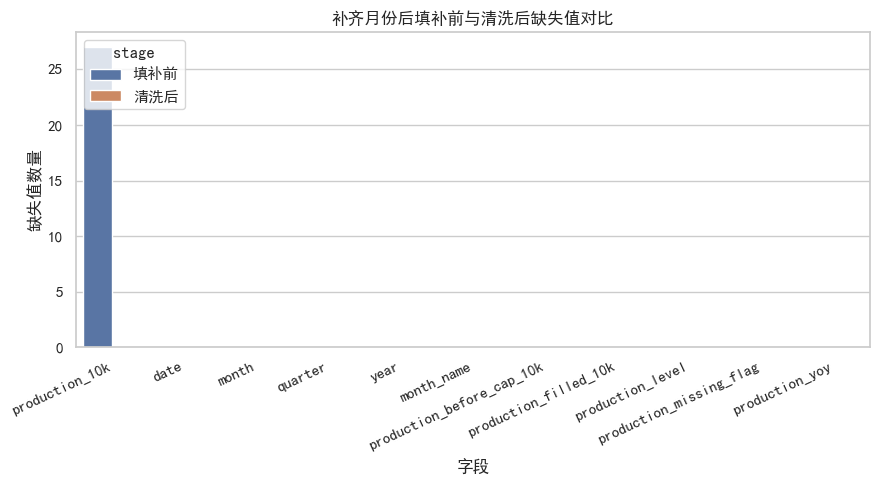

图 01 和图 05 属于数据清洗前后对比；图 02、03、04、06、07、08 属于清洗后数据分析结果。


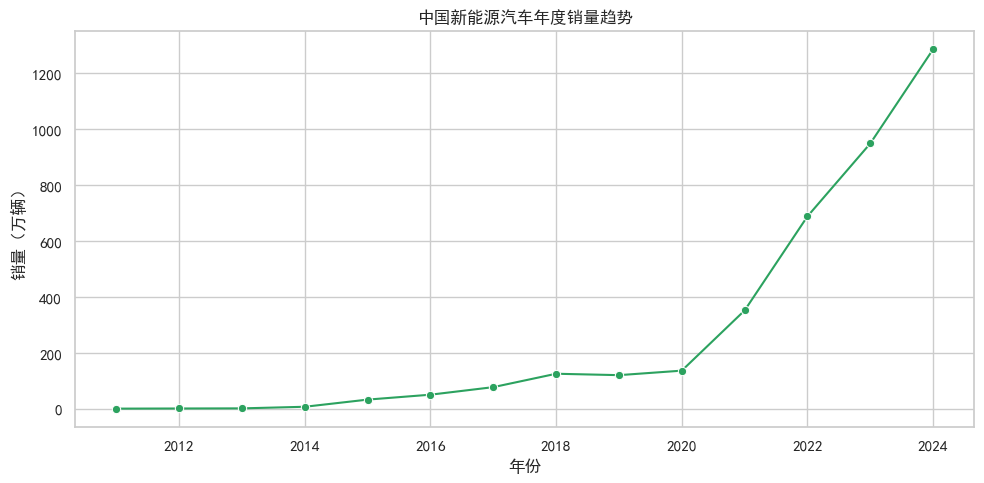

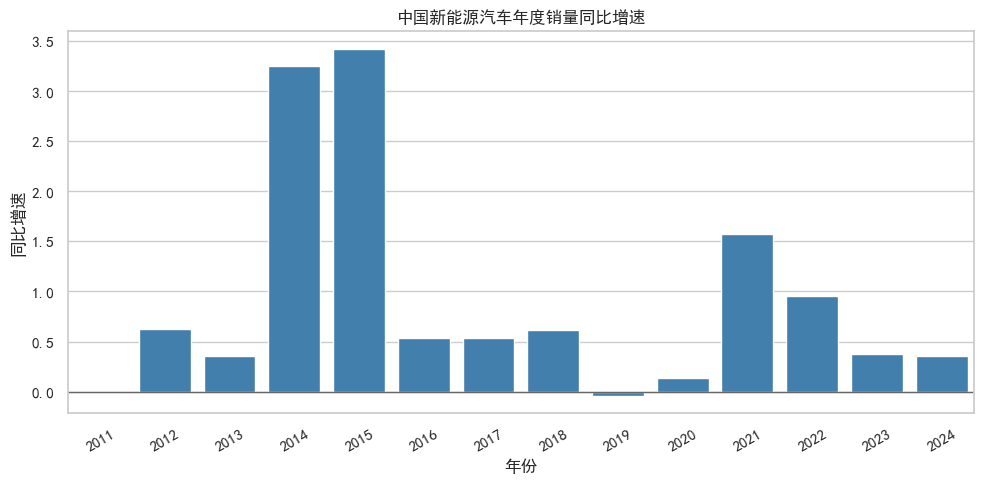

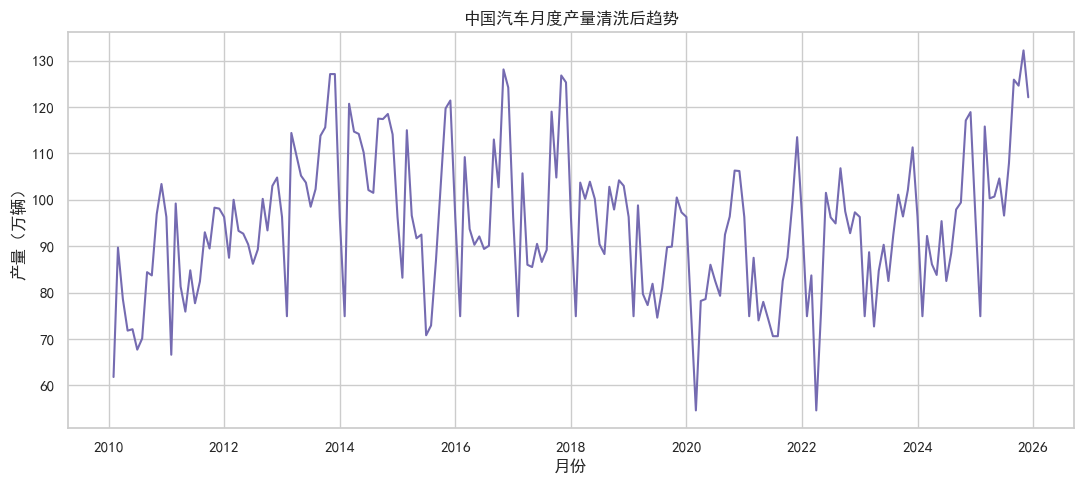

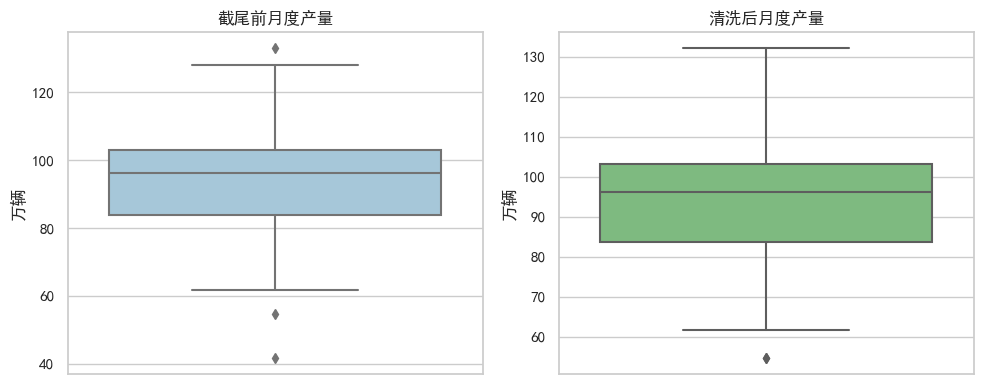

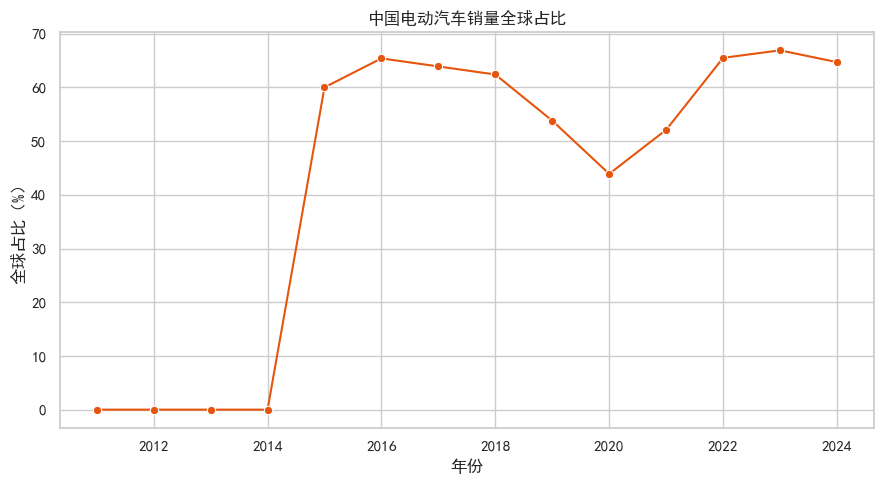

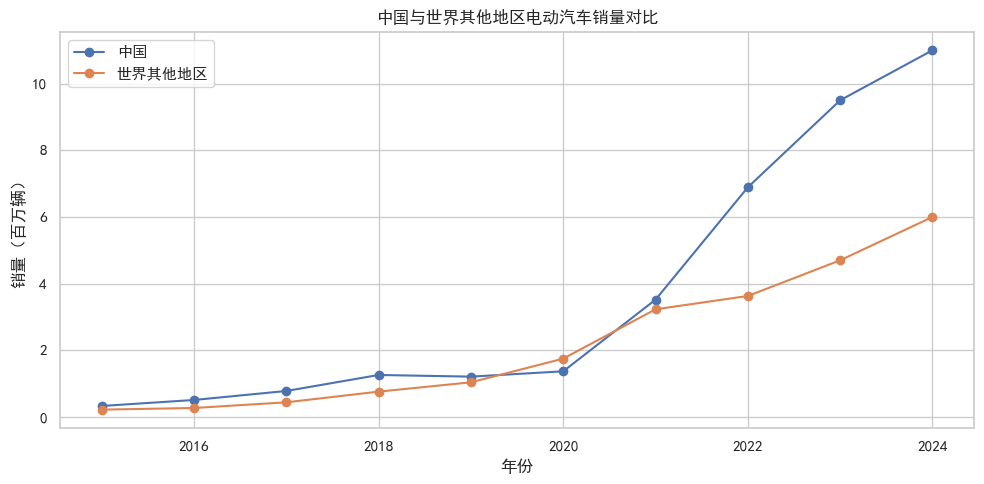

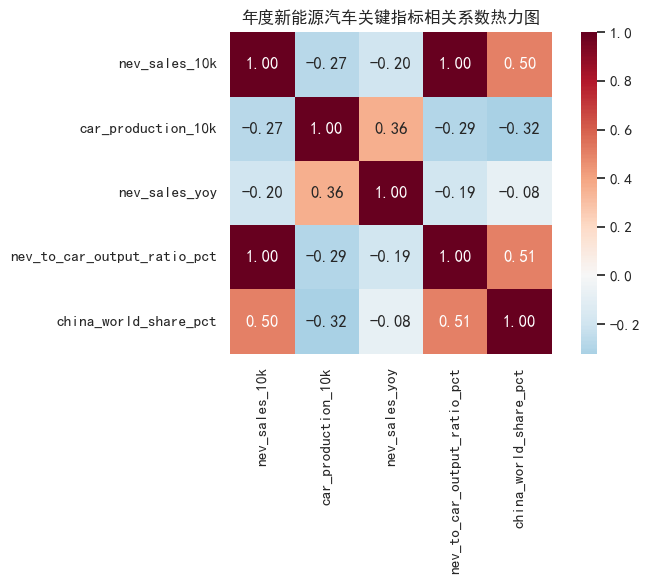

In [7]:
def save_current_fig(name: str) -> None:
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=200)
    plt.show()


merged_missing = pd.concat([missing_before, missing_after], ignore_index=True)
plt.figure(figsize=(9, 5))
sns.barplot(data=merged_missing, x="column", y="missing_count", hue="stage")
plt.title("补齐月份后填补前与清洗后缺失值对比")
plt.xlabel("字段")
plt.ylabel("缺失值数量")
plt.xticks(rotation=25, ha="right")
save_current_fig("01_missing_before_after.png")

print("图 01 和图 05 属于数据清洗前后对比；图 02、03、04、06、07、08 属于清洗后数据分析结果。")

plt.figure(figsize=(10, 5))
sns.lineplot(data=annual, x="year", y="nev_sales_10k", marker="o", color="#2ca25f")
plt.title("中国新能源汽车年度销量趋势")
plt.xlabel("年份")
plt.ylabel("销量（万辆）")
save_current_fig("02_nev_sales_trend.png")

plt.figure(figsize=(10, 5))
sns.barplot(data=annual, x="year", y="nev_sales_yoy", color="#3182bd")
plt.axhline(0, color="#666666", linewidth=1)
plt.title("中国新能源汽车年度销量同比增速")
plt.xlabel("年份")
plt.ylabel("同比增速")
plt.xticks(rotation=30)
save_current_fig("03_nev_yoy_growth.png")

plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_clean, x="date", y="production_filled_10k", color="#756bb1")
plt.title("中国汽车月度产量清洗后趋势")
plt.xlabel("月份")
plt.ylabel("产量（万辆）")
save_current_fig("04_monthly_car_production.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=monthly_clean["production_before_cap_10k"], ax=axes[0], color="#9ecae1")
axes[0].set_title("截尾前月度产量")
axes[0].set_ylabel("万辆")
sns.boxplot(y=monthly_clean["production_filled_10k"], ax=axes[1], color="#74c476")
axes[1].set_title("清洗后月度产量")
axes[1].set_ylabel("万辆")
save_current_fig("05_production_boxplot_before_after.png")

plt.figure(figsize=(9, 5))
sns.lineplot(data=annual, x="year", y="china_world_share_pct", marker="o", color="#e6550d")
plt.title("中国电动汽车销量全球占比")
plt.xlabel("年份")
plt.ylabel("全球占比（%）")
save_current_fig("06_china_world_share.png")

compare = annual[annual["world_ev_sales_million"] > 0]
plt.figure(figsize=(10, 5))
plt.plot(compare["year"], compare["china_ev_sales_million"], marker="o", label="中国")
plt.plot(compare["year"], compare["world_minus_china_million"], marker="o", label="世界其他地区")
plt.title("中国与世界其他地区电动汽车销量对比")
plt.xlabel("年份")
plt.ylabel("销量（百万辆）")
plt.legend()
save_current_fig("07_china_vs_world_ev_sales.png")

corr_cols = ["nev_sales_10k", "car_production_10k", "nev_sales_yoy", "nev_to_car_output_ratio_pct", "china_world_share_pct"]
plt.figure(figsize=(8, 6))
sns.heatmap(annual[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("年度新能源汽车关键指标相关系数热力图")
save_current_fig("08_annual_correlation_heatmap.png")

## 8. 结果解释

清洗后月度数据共 191 行、年度分析表共 14 行，两个清洗结果的缺失值总数均为 0。月度汽车产量数据通过完整月份序列补齐后，新增了 27 条原始未报告月份，并用同月历史中位数进行填补，避免时间序列分析时出现断点。

从年度趋势看，中国新能源汽车销量从 2011 年的较小规模增长到 2024 年的 1286.6 万辆，体现出新能源汽车产业的快速扩张。2021 年以后销量增长尤其明显，与国内新能源汽车政策支持、产业链成熟、充电基础设施完善和消费者接受度提升有关。全球对比数据也显示，中国电动汽车销量在全球市场中占据较高比例，说明中国已经成为全球新能源汽车发展的重要市场。

In [8]:
print(f"清洗后月度数据: {monthly_clean.shape[0]} 行, {monthly_clean.shape[1]} 列")
print(f"清洗后年度数据: {annual.shape[0]} 行, {annual.shape[1]} 列")
print(f"月度清洗表缺失值: {int(monthly_clean.isna().sum().sum())}")
print(f"年度清洗表缺失值: {int(annual.isna().sum().sum())}")
print(f"2024 年新能源汽车销量: {quality_summary['latest_nev_sales_10k']} 万辆")
print(f"2024 年中国电动汽车销量全球占比: {quality_summary['latest_china_world_share_pct']}%")

清洗后月度数据: 191 行, 11 列
清洗后年度数据: 14 行, 13 列
月度清洗表缺失值: 0
年度清洗表缺失值: 0
2024 年新能源汽车销量: 1286.6 万辆
2024 年中国电动汽车销量全球占比: 64.7%


## 9. 文献综述与参考文献

国内数据清洗研究普遍认为，数据质量问题主要包括缺失、不一致、重复、异常和格式不规范等类型。郭志懋、周傲英对数据质量和数据清洗问题进行了较早综述，强调数据清洗应当结合数据剖析、错误检测、转换修复和质量验证。后续研究进一步关注结构化数据清洗、可视化数据清洗和大数据环境下的并行清洗方法。结合本案例可以看到，新能源汽车数据虽然不是传统脏数据集，但仍然存在时间序列不完整、指标口径差异、缺失月份需要标记、异常月份需要检查等问题。

新能源汽车相关政策和产业规划也说明，新能源汽车是我国汽车产业转型升级的重要方向。用中国新能源汽车销量和汽车产量数据开展清洗与分析，不仅能满足课程的数据处理要求，也能把数据清洗技术放在真实产业背景中理解。

[1] 郭志懋, 周傲英. 数据质量和数据清洗研究综述[J]. 软件学报, 2002, 13(11): 2076-2082.  
[2] 杨辅祥, 刘云超, 段智华. 数据清理综述[J]. 计算机应用研究, 2002, 19(3): 3-5.  
[3] 王曰芬, 章成志, 张蓓蓓, 等. 数据清洗研究综述[J]. 现代图书情报技术, 2007(12): 50-56.  
[4] 赵一凡, 卞良, 丛昕. 数据清洗方法研究综述[J]. 软件导刊, 2017, 16(12): 222-224.  
[5] 郝爽, 李国良, 冯建华, 等. 结构化数据清洗方法综述[J]. 清华大学学报(自然科学版), 2018, 58(12): 1037-1050.  
[6] 王铭军, 潘巧明, 刘真, 陈为. 可视数据清洗综述[J]. 中国图象图形学报, 2015, 20(4): 468-482.  
[7] 杨东华, 李宁宁, 王宏志, 等. 基于任务合并的并行大数据清洗过程优化[J]. 计算机学报, 2016, 39(1): 97-108.  
[8] 国家市场监督管理总局, 中国国家标准化管理委员会. 信息技术 数据质量评价指标: GB/T 36344-2018[S]. 北京: 中国标准出版社, 2018.  
[9] 国务院办公厅. 新能源汽车产业发展规划(2021-2035年)[Z]. 2020.  
[10] China Data Portal. China NEV Sales, China Monthly Car Production, Electric Vehicle Sales: China vs World[DS/OL]. 2026.